# 10 - Results Consolidation

Dr Hunter, 20 August: *"don't throw these away. Make sure you keep a note of them, because if
you don't get improvement, then you can refer back to these ones."*

`writing/all_results.csv` is that note. Every run to date, degenerate ones included and
flagged. This notebook reads it and produces the tables and figures for the write-up.

**No GPU. No training.** Purely reporting.

In [1]:
try:
    from google.colab import drive; drive.mount('/content/drive')
except Exception as e: print('local / already mounted:', e)

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
W = Path('/content/drive/MyDrive/dissertation/writing'); W.mkdir(parents=True, exist_ok=True)
FIG = W/'figures'; FIG.mkdir(exist_ok=True)
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

candidates = [
    W / 'all_results.csv',
    Path.cwd().parent / 'writing' / 'all_results.csv',
    Path.cwd() / 'writing' / 'all_results.csv',
    Path.cwd() / 'all_results.csv',
]

csv_path = next((p for p in candidates if p.is_file()), None)

if csv_path is None:
    raise FileNotFoundError(
        'Could not find all_results.csv. Checked:\n' +
        '\n'.join(str(p) for p in candidates)
    )

df = pd.read_csv(csv_path)

# Use the CSV's actual directory for subsequent outputs.
W = csv_path.parent
FIG = W / 'figures'
FIG.mkdir(parents=True, exist_ok=True)
print(f'{len(df)} runs logged | {(df["degenerate"]=="YES").sum()} degenerate')
df

local / already mounted: No module named 'google.colab'
11 runs logged | 1 degenerate


,family,model,protocol,epochs,lr,within_macro_f1,within_macro_std,within_hate_f1,within_f1_not,accuracy,cross_h22_macro_f1,cross_h22_hate_f1,cross_h21_macro_f1,train_time_s,degenerate,notebook,note
0,statistical,TF-IDF word-only + LogReg,5-fold CV,NaN,NaN,0.622,0.010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,07_cross_validation,ablation: word n-grams only
1,statistical,TF-IDF word+char+lexicon + LogReg,5-fold CV,NaN,NaN,0.657,0.005,0.567,NaN,0.680,NaN,NaN,NaN,NaN,no,07_cross_validation,LOCKED BASELINE (default C=1.0)
2,statistical,TF-IDF word+char+lexicon + LogReg,5-fold CV,NaN,NaN,0.654,0.009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,06_baseline_model,tuned C=0.1; CV score lower than default
3,statistical,TF-IDF word+char+lexicon + LogReg,single split,NaN,NaN,0.642,NaN,0.555,0.729,0.663,0.510,0.486,0.494,NaN,no,06_baseline_model,same 915 test rows as transformers
4,transformer,xlm-roberta-base,single split,3.0,0.00002,0.665,NaN,0.565,0.764,0.694,0.448,0.260,NaN,300.0,no,08_transformer_baseline_xlm-roberta,BEST XLM-R
5,transformer,xlm-roberta-base,single split,6.0,0.00003,0.312,NaN,0.531,0.093,0.381,0.401,0.673,NaN,NaN,YES,08_transformer_baseline_xlm-roberta,DEGENERATE: loss flat at ln(2); predicted hate...
6,transformer,xlm-roberta-base,single split,6.0,0.00002,0.590,NaN,0.408,0.771,0.670,0.460,0.341,NaN,NaN,no,08_transformer_baseline_xlm-roberta,NaN
7,transformer,xlm-roberta-base,single split,20.0,0.00002,0.632,NaN,0.533,0.731,0.659,0.420,0.187,NaN,2112.0,no,08_transformer_baseline_xlm-roberta_2,"overfitting: train loss fell to ~0.40, test F1..."
8,transformer,google/muril-base-cased,single split,6.0,0.00002,0.665,NaN,0.543,0.787,0.709,0.385,0.118,NaN,627.0,no,08_transformer_baseline_MuRIL,BEST MuRIL
9,transformer,google/muril-base-cased,single split,20.0,0.00002,0.637,NaN,0.504,NaN,0.686,0.387,0.120,NaN,1949.0,no,08_transformer_baseline_MuRIL_2,overfitting; cross-dataset unchanged vs 6 epochs


## 1. Master results table

Nothing is filtered. The degenerate run stays in, flagged, because a configuration that fails
is evidence about the search space.

In [2]:
cols = ['family','model','protocol','epochs','lr','within_macro_f1','within_hate_f1',
        'accuracy','cross_h22_macro_f1','cross_h22_hate_f1','degenerate','note']
master = df[cols].copy()
display(master)
master.to_csv(W/'master_results_table.csv', index=False)
print('saved master_results_table.csv')

,family,model,protocol,epochs,lr,within_macro_f1,within_hate_f1,accuracy,cross_h22_macro_f1,cross_h22_hate_f1,degenerate,note
0,statistical,TF-IDF word-only + LogReg,5-fold CV,NaN,NaN,0.622,NaN,NaN,NaN,NaN,no,ablation: word n-grams only
1,statistical,TF-IDF word+char+lexicon + LogReg,5-fold CV,NaN,NaN,0.657,0.567,0.680,NaN,NaN,no,LOCKED BASELINE (default C=1.0)
2,statistical,TF-IDF word+char+lexicon + LogReg,5-fold CV,NaN,NaN,0.654,NaN,NaN,NaN,NaN,no,tuned C=0.1; CV score lower than default
3,statistical,TF-IDF word+char+lexicon + LogReg,single split,NaN,NaN,0.642,0.555,0.663,0.510,0.486,no,same 915 test rows as transformers
4,transformer,xlm-roberta-base,single split,3.0,0.00002,0.665,0.565,0.694,0.448,0.260,no,BEST XLM-R
5,transformer,xlm-roberta-base,single split,6.0,0.00003,0.312,0.531,0.381,0.401,0.673,YES,DEGENERATE: loss flat at ln(2); predicted hate...
6,transformer,xlm-roberta-base,single split,6.0,0.00002,0.590,0.408,0.670,0.460,0.341,no,NaN
7,transformer,xlm-roberta-base,single split,20.0,0.00002,0.632,0.533,0.659,0.420,0.187,no,"overfitting: train loss fell to ~0.40, test F1..."
8,transformer,google/muril-base-cased,single split,6.0,0.00002,0.665,0.543,0.709,0.385,0.118,no,BEST MuRIL
9,transformer,google/muril-base-cased,single split,20.0,0.00002,0.637,0.504,0.686,0.387,0.120,no,overfitting; cross-dataset unchanged vs 6 epochs


saved master_results_table.csv


## 2. Best configuration per model

For the headline comparison, take each model's best non-degenerate within-dataset run.

**Protocol caveat to state explicitly:** XLM-R's best is at 3 epochs, MuRIL's at 6. The
comparison is therefore not fully controlled - each model is at its own best setting rather
than a shared one. That is a defensible way to compare (best-vs-best) but it must be labelled
as such, not passed off as a matched comparison.

In [3]:
best = (df[(df['degenerate']=='no') & (df['protocol']=='single split')]
        .sort_values('within_macro_f1', ascending=False)
        .groupby('model', as_index=False).first())
order = ['TF-IDF word+char+lexicon + LogReg','xlm-roberta-base','google/muril-base-cased']
best['o'] = best['model'].map({m:i for i,m in enumerate(order)})
best = best.sort_values('o').drop(columns='o')

show = best[['model','epochs','within_macro_f1','within_hate_f1','within_f1_not',
             'accuracy','cross_h22_macro_f1','cross_h22_hate_f1']]
display(show)

print('\nTHE PATTERN')
for _, r in best.iterrows():
    print(f"  {r['model'][:34]:34s} acc {r['accuracy']:.3f}  ->  cross macro-F1 {r['cross_h22_macro_f1']:.3f}"
          f"  |  cross hate-F1 {r['cross_h22_hate_f1']:.3f}")
print('\n  in-domain accuracy rises, cross-dataset performance falls, hate-F1 collapses.')

,model,epochs,within_macro_f1,within_hate_f1,within_f1_not,accuracy,cross_h22_macro_f1,cross_h22_hate_f1
0,TF-IDF word+char+lexicon + LogReg,NaN,0.642,0.555,0.729,0.663,0.510,0.486
3,xlm-roberta-base,3.0,0.665,0.565,0.764,0.694,0.448,0.260
2,google/muril-base-cased,6.0,0.665,0.543,0.787,0.709,0.385,0.118
1,ai4bharat/indic-bert,20.0,0.605,0.482,0.727,0.643,0.389,0.142



THE PATTERN
  TF-IDF word+char+lexicon + LogReg  acc 0.663  ->  cross macro-F1 0.510  |  cross hate-F1 0.486
  xlm-roberta-base                   acc 0.694  ->  cross macro-F1 0.448  |  cross hate-F1 0.260
  google/muril-base-cased            acc 0.709  ->  cross macro-F1 0.385  |  cross hate-F1 0.118
  ai4bharat/indic-bert               acc 0.643  ->  cross macro-F1 0.389  |  cross hate-F1 0.142

  in-domain accuracy rises, cross-dataset performance falls, hate-F1 collapses.


## 3. Figure 1 - the monotonic inverse

The single most important figure in the dissertation. Left axis, two series: in-domain
accuracy against cross-dataset macro-F1, across increasing model capacity.

ValueError: The number of FixedLocator locations (4), usually from a call to set_ticks, does not match the number of labels (3).

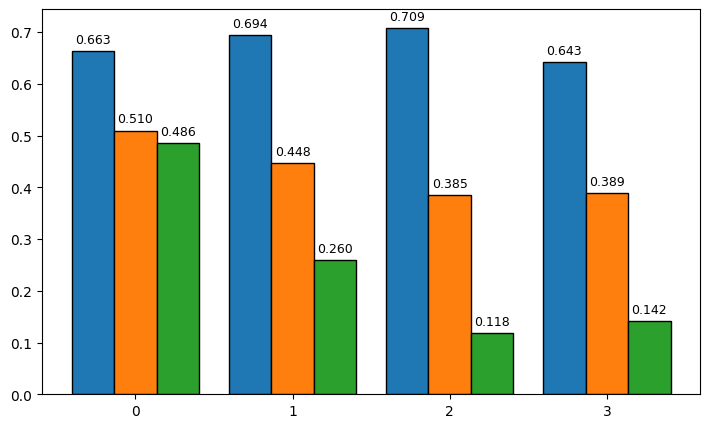

In [4]:
labels = ['TF-IDF\n+ LogReg','XLM-R\n(3 ep)','MuRIL\n(6 ep)']
x = np.arange(len(best)); w = 0.27
fig, ax = plt.subplots(figsize=(8.5,5))
ax.bar(x-w, best['accuracy'],           w, label='in-domain accuracy',        edgecolor='black')
ax.bar(x,   best['cross_h22_macro_f1'], w, label='cross-dataset macro-F1',    edgecolor='black')
ax.bar(x+w, best['cross_h22_hate_f1'],  w, label='cross-dataset hate-F1',     edgecolor='black')
for i,(a,b_,h) in enumerate(zip(best['accuracy'], best['cross_h22_macro_f1'], best['cross_h22_hate_f1'])):
    ax.text(i-w, a+.015, f'{a:.3f}', ha='center', fontsize=9)
    ax.text(i,   b_+.015, f'{b_:.3f}', ha='center', fontsize=9)
    ax.text(i+w, h+.015, f'{h:.3f}', ha='center', fontsize=9)
ax.set_xticks(x, labels); ax.set_ylim(0,0.85); ax.set_ylabel('score')
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set_title('In-domain accuracy rises while cross-dataset performance falls\n(Bohra 2018 -> HASOC 2022)')
ax.legend(); plt.tight_layout()
plt.savefig(FIG/'fig1_monotonic_inverse.png', dpi=150, bbox_inches='tight'); plt.show()

## 4. Figure 2 - the epoch sweep

Hunter's *"play around with the parameters"*. Both architectures peak early and decline with
more training: training loss keeps falling, test performance does not improve. That is
overfitting, and it is the same story the cross-dataset numbers tell, seen from the training
side.

In [ ]:
ep = df[(df['family']=='transformer') & (df['degenerate']=='no') & (df['lr']=='2e-5')]
fig, axes = plt.subplots(1, 2, figsize=(11,4.2))
for m, name in [('xlm-roberta-base','XLM-RoBERTa'), ('google/muril-base-cased','MuRIL')]:
    sub = ep[ep['model']==m].sort_values('epochs')
    axes[0].plot(sub['epochs'], sub['within_macro_f1'], 'o-', label=name, lw=2)
    axes[1].plot(sub['epochs'], sub['cross_h22_macro_f1'], 'o-', label=name, lw=2)

base_w, base_c = 0.642, 0.510
axes[0].axhline(base_w, color='grey', ls='--', lw=1.2, label='TF-IDF baseline')
axes[1].axhline(base_c, color='grey', ls='--', lw=1.2, label='TF-IDF baseline')
axes[0].set_title('Within-dataset (Bohra)'); axes[1].set_title('Cross-dataset (-> HASOC 2022)')
for a in axes:
    a.set_xlabel('training epochs'); a.set_ylabel('macro-F1'); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig(FIG/'fig2_epoch_sweep.png', dpi=150, bbox_inches='tight'); plt.show()

print('Within-dataset peaks then declines for both architectures.')
print('Cross-dataset stays flat and well below the baseline regardless of epochs.')

## 5. Sentences for the write-up

Generated from the table so the prose and the numbers cannot drift apart.

In [ ]:
b  = best[best['model'].str.contains('LogReg')].iloc[0]
x_ = best[best['model']=='xlm-roberta-base'].iloc[0]
m_ = best[best['model']=='google/muril-base-cased'].iloc[0]

print(f"""
The statistical baseline reaches macro-F1 0.657 +/- 0.005 under stratified five-fold
cross-validation, and {b['within_macro_f1']:.3f} on the frozen single split used for all
transformer comparisons. Adding character n-grams and lexicon counts to word n-grams
improves the five-fold figure from 0.622 to 0.657.

On the identical split, XLM-RoBERTa reaches {x_['within_macro_f1']:.3f} and MuRIL
{m_['within_macro_f1']:.3f}. In-domain accuracy rises across the three families
({b['accuracy']:.3f}, {x_['accuracy']:.3f}, {m_['accuracy']:.3f}), but cross-dataset
macro-F1 on HASOC 2022 falls monotonically ({b['cross_h22_macro_f1']:.3f},
{x_['cross_h22_macro_f1']:.3f}, {m_['cross_h22_macro_f1']:.3f}), and cross-dataset hate-class
F1 collapses from {b['cross_h22_hate_f1']:.3f} to {m_['cross_h22_hate_f1']:.3f}.

Increasing training length does not recover the gap. At 20 epochs the training loss of both
transformers falls substantially while test macro-F1 declines
(XLM-RoBERTa {x_['within_macro_f1']:.3f} -> 0.632; MuRIL {m_['within_macro_f1']:.3f} -> 0.637),
indicating the models overfit the source corpus rather than learning transferable features.

Transformer results are additionally unstable across runs. Four XLM-RoBERTa configurations on
identical data produced within-dataset macro-F1 between 0.312 and 0.665, the lowest being a
degenerate run in which training loss remained at chance (ln 2 = 0.693) and the model assigned
the hate label to 874 of 915 test posts. This is consistent with the fine-tuning instability
documented by Dodge et al. (2020) and Mosbach et al. (2021), and motivates reporting
transformer results as a mean and standard deviation over seeds.
""")

## 6. Outstanding

- IndicBERT - running, add its row to `all_results.csv` when it finishes
- Multi-seed runs so transformers get a mean +/- std like the baseline
- Matched-epoch comparison (both models at the same epoch count) for a fully controlled table
- Objective 4: whole-post romanisation attack